# Technique A and Technique B, both into `Polygon2d`

The same Monte Carlo label image, geometrified two independent ways, both landing on
the same UPXO-native `Polygon2d` type:

- **Technique A** (`polygonised_grain_structure`) builds `Polygon2d` **natively** --
  `construct_geometric_xtals_from_gbcoords(..., dtype='upxo')` wraps the `ring2d` it
  already built (`self.GB[gid]`) with zero copying. No converter needed; pixel-exact,
  unsmoothed boundaries.
- **Technique B** (`GrainManifold2D`) produces Shapely polygons only -- Taubin-smoothed
  Voronoi-cell unions -- so it goes through `polygon_collection_from_shapely`, the new
  converter, to reach the same `Polygon2d` type with the same shared-wall-identity
  guarantee.

Both paths are demonstrated end to end: converted, plotted, and edited.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from pathlib import Path
from shapely.geometry import MultiPolygon

from upxo.ggrowth.mcgs import mcgs
from upxo._sup.raster_islands import find_island_regions
import upxo.gsdataops.grid_ops as gridOps
from upxo.pxtal.geometrification import polygonised_grain_structure, GrainManifold2D
from upxo.geoEntities.polygon2d import Polygon2d, NestedPolygon2d
from upxo.geoEntities.polygon2d_from_shapely import polygon_collection_from_shapely
from upxo.viz import gsviz

def _outer_ring(poly):
    # NestedPolygon2d has no .ring of its own -- its outer boundary is
    # poly.host.ring; a plain Polygon2d's boundary is poly.ring directly.
    return poly.ring if hasattr(poly, 'ring') else poly.host.ring

def _editable(poly):
    # edit_segment/subdivide_segment live on Polygon2d; a NestedPolygon2d
    # delegates its outer boundary to .host (itself a plain Polygon2d).
    return poly if hasattr(poly, 'ring') else poly.host

def find_shared_segment(poly_a, poly_b):
    for ia, sa in enumerate(_outer_ring(poly_a).segments):
        for ib, sb in enumerate(_outer_ring(poly_b).segments):
            if sa is sb:
                return ia, ib, sa
    return None

def any_shared_pair(result):
    gids = list(result.keys())
    for i, ga in enumerate(gids):
        for gb in gids[i + 1:]:
            m = find_shared_segment(result[ga], result[gb])
            if m is not None:
                return (ga, gb, *m)
    return None

## 1. One Monte Carlo label image, shared by both techniques

In [2]:
_XLS = next(
    (p / "src" / "upxo" / "demos" / "confMesh" / "confMesh1.xls"
     for p in [Path.cwd(), *Path.cwd().parents]
     if (p / "src" / "upxo" / "demos" / "confMesh" / "confMesh1.xls").is_file()),
    Path("confMesh1.xls"),
)
np.random.seed(0)

pxt = mcgs(input_dashboard=str(_XLS))
pxt.simulate()
pxt.detect_grains(library="cc3d", connectivity=4)

# Coarsest time slice that still contains island grains (a grain fully
# enclosed by another). Fewer grains keeps the plots readable, and an island
# is what makes Technique A return a NestedPolygon2d.
slice_keys = list(pxt.gs.keys())
with_islands = [i for i, k in enumerate(slice_keys)
                if find_island_regions(pxt.gs[k].lgi)[2]]
SLICE = min(with_islands, key=lambda i: len(np.unique(pxt.gs[slice_keys[i]].lgi)))
gstslice = pxt.gs[slice_keys[SLICE]]
lgi = gstslice.lgi
n_islands = len(find_island_regions(lgi)[2])
print(f"slice {SLICE}: image {lgi.shape}, {len(np.unique(lgi))} grains, "
      f"{n_islands} island cluster(s)")

C:\Development\UPXO\upxo_library\src\upxo\interfaces\user_inputs
C:\Development\UPXO\upxo_library\src\upxo\demos\confMesh\confMesh1.xls
Algo_hops details
(('200.0', 100),)
[False]

 Initiating Monte-Carlo simulation
     xmin, xmax, xinc: 0.0, 50.0, 1.0
     ymin, ymax, yinc: 0.0, 50.0, 1.0
     zmin, zmax, zinc: 0.0, 100.0, 1.0
     No. of states: 20
     Dimensionality: 2


Using ALG-200: SA's SL NL-1 TP1 C2 unweighted Q-Pott's model:
|--------------- MC SIM RUN IN PROGRESS on: ALG200---------------|


GS temporal slice 0 stored
GS temporal slice 1 stored
GS temporal slice 2 stored
GS temporal slice 3 stored
GS temporal slice 4 stored
GS temporal slice 5 stored
GS temporal slice 6 stored
GS temporal slice 7 stored
GS temporal slice 8 stored
GS temporal slice 9 stored
|--------------- MC SIM RUN COMPLETED on: ALG200---------------|
Using cc3d for grain identification
slice 8: image (51, 51), 69 grains, 1 island cluster(s)


## 2. Technique A -- native `Polygon2d`, no converter

`construct_geometric_xtals_from_gbcoords(..., dtype='upxo')` returns one entry per grain.

- A grain that fully encloses another grain (an island) is a `NestedPolygon2d`: its outer
  boundary plus one hole per island it directly encloses.
- Every other grain, including each island itself, is a `Polygon2d`.
- An island's boundary is the same object in its own `Polygon2d` and in its host's hole,
  so an edit made through either one is seen by both.
- An island inside an island is a hole of its immediate parent, not of the outer host.

Technique A: 69 grains, 1 with island hole(s) (NestedPolygon2d), 68 plain Polygon2d
total area: 2601.0000


Text(0.5, 1.0, 'Technique A -> Polygon2d (pixel-exact, unsmoothed)')

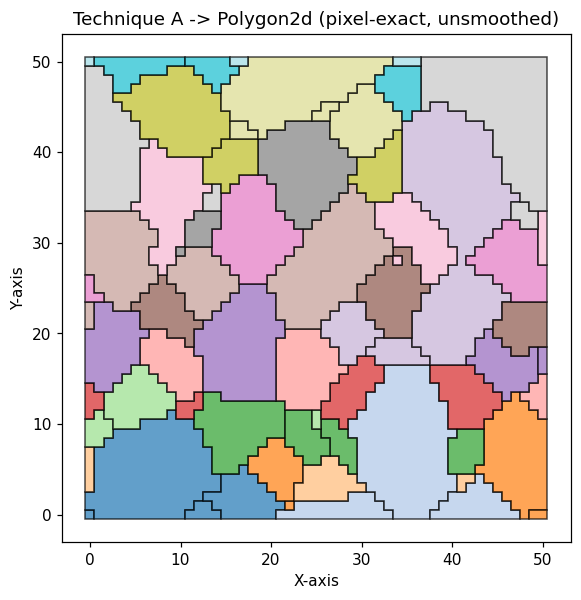

In [3]:
geoA = polygonised_grain_structure(lgi, np.unique(lgi), None)
geoA.pix_to_geom(verbose=False)
resultA = geoA.construct_geometric_xtals_from_gbcoords(geoA.GBCoords, dtype='upxo', saa=False, throw=True)
n_nested = sum(1 for p in resultA.values() if isinstance(p, NestedPolygon2d))
print(f"Technique A: {len(resultA)} grains, {n_nested} with island hole(s) "
     f"(NestedPolygon2d), {sum(1 for p in resultA.values() if type(p).__name__ == 'Polygon2d')} plain Polygon2d")
print(f"total area: {sum(p.area for p in resultA.values()):.4f}")

fig, ax = plt.subplots(figsize=(6, 6), dpi=110)
gsviz.plot_multipolygon_geometric(
    MultiPolygon([p.make_shapely() for p in resultA.values()]), fig=fig, ax=ax)
ax.set_title('Technique A -> Polygon2d (pixel-exact, unsmoothed)')

### Island grains

One host and the island it encloses, from the structure above. The island's outline is drawn
in red over the full grain structure.

grains that enclose an island: [38]
grain 38: NestedPolygon2d, hole grain ids [48], net area 48.0000
grain 48: Polygon2d, area 1.0000
island boundary is the host's hole boundary: True


Text(0.5, 1.0, 'Grain 38 and the island it encloses')

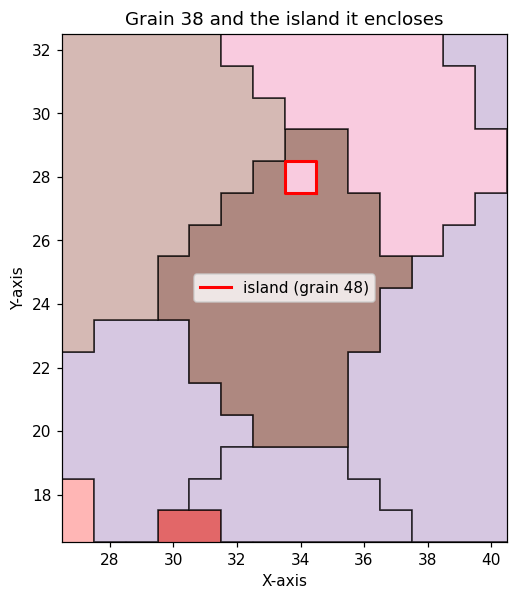

In [4]:
hosts = [int(gid) for gid, p in resultA.items() if isinstance(p, NestedPolygon2d)]
host_gid = hosts[0]
host = resultA[host_gid]
island = resultA[host.holes[0].gid]

print(f"grains that enclose an island: {hosts}")
print(f"grain {host_gid}: NestedPolygon2d, hole grain ids {[int(h.gid) for h in host.holes]}, "
      f"net area {host.area:.4f}")
print(f"grain {island.gid}: {type(island).__name__}, area {island.area:.4f}")
print(f"island boundary is the host's hole boundary: {host.holes[0].ring is island.ring}")

minx, miny, maxx, maxy = host.make_shapely().bounds
pad = 3
fig, ax = plt.subplots(figsize=(6, 6), dpi=110)
gsviz.plot_multipolygon_geometric(
    MultiPolygon([p.make_shapely() for p in resultA.values()]), fig=fig, ax=ax)
hx, hy = host.holes[0].make_shapely().exterior.xy
ax.plot(hx, hy, 'r-', lw=2, label=f'island (grain {island.gid})')
ax.set_xlim(minx - pad, maxx + pad)
ax.set_ylim(miny - pad, maxy + pad)
ax.legend()
ax.set_title(f'Grain {host_gid} and the island it encloses')

## 3. Technique B -- via `polygon_collection_from_shapely`

Technique B: 69 grains, all {'Polygon2d', 'NestedPolygon2d'}
total area: 2601.0000


Text(0.5, 1.0, 'Technique B -> Polygon2d (Taubin-smoothed)')

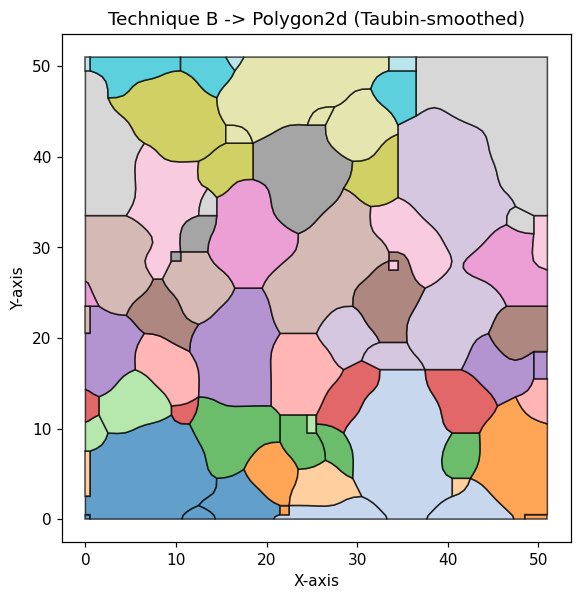

In [5]:
seeds = gridOps.generate_constrained_hybrid_seeds(
    lgi, target_spacing=1.0, bulk_spacing=1.0,
    jitter_factor=0.25, margin=0.5, padding=2.0)
manifold = GrainManifold2D.by_tessellation(lgi, seeds)
manifold.smooth_interfaces(iterations=10, lmbda=0.5, mu=-0.53)
cellsB = dict(manifold.cells)

resultB = polygon_collection_from_shapely(cellsB, verbose=False)
print(f"Technique B: {len(resultB)} grains, all {set(type(p).__name__ for p in resultB.values())}")
print(f"total area: {sum(p.area for p in resultB.values()):.4f}")

fig, ax = plt.subplots(figsize=(6, 6), dpi=110)
gsviz.plot_multipolygon_geometric(
    MultiPolygon([p.make_shapely() for p in resultB.values()]), fig=fig, ax=ax)
ax.set_title('Technique B -> Polygon2d (Taubin-smoothed)')

## 4. Comparison

               grains   total area
Technique A        69    2601.0000
Technique B        69    2601.0000


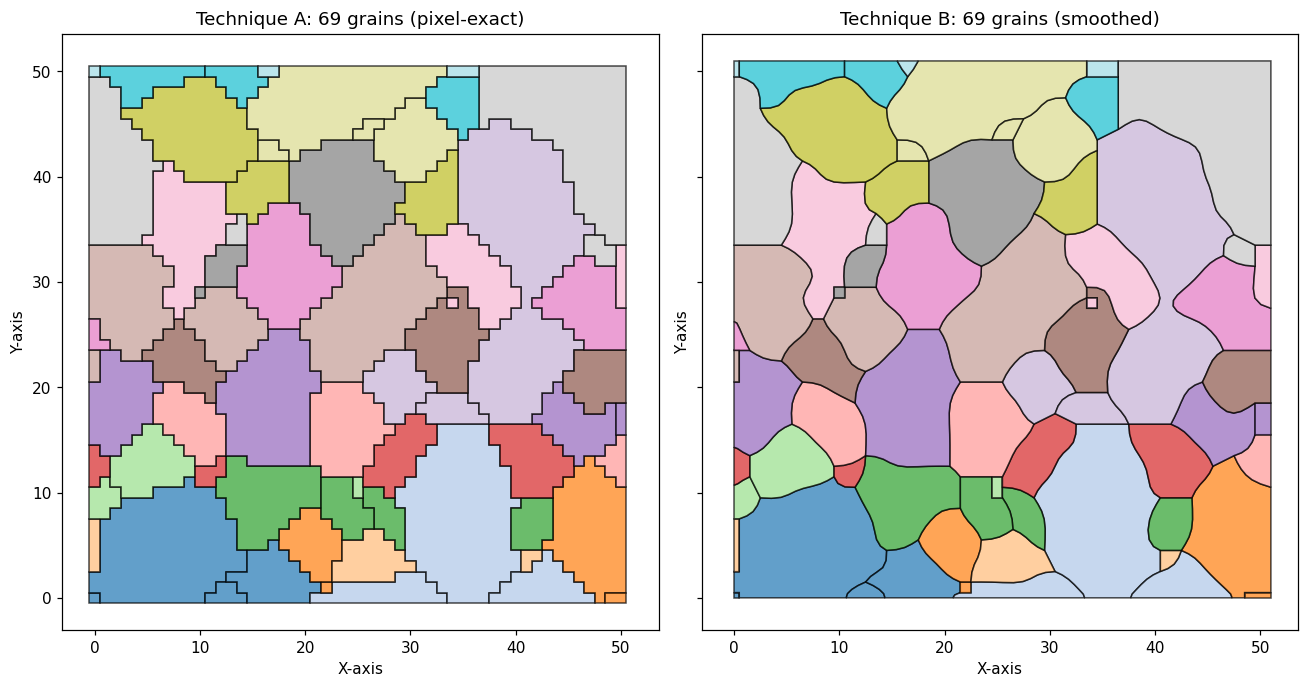

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6), dpi=110, sharex=True, sharey=True)
gsviz.plot_multipolygon_geometric(
    MultiPolygon([p.make_shapely() for p in resultA.values()]), fig=fig, ax=axes[0])
axes[0].set_title(f'Technique A: {len(resultA)} grains (pixel-exact)')
gsviz.plot_multipolygon_geometric(
    MultiPolygon([p.make_shapely() for p in resultB.values()]), fig=fig, ax=axes[1])
axes[1].set_title(f'Technique B: {len(resultB)} grains (smoothed)')
fig.tight_layout()

print(f"{'':12s} {'grains':>8s} {'total area':>12s}")
print(f"{'Technique A':12s} {len(resultA):8d} {sum(p.area for p in resultA.values()):12.4f}")
print(f"{'Technique B':12s} {len(resultB):8d} {sum(p.area for p in resultB.values()):12.4f}")

## 5. Editable grain structures

One shared-wall edit on each structure, confirming the same `edit_segment` mechanism
works identically regardless of which technique produced the `Polygon2d` collection.

Technique A: no gap=True, area 2601.0000 -> 2601.0000 (conserved: True)
Technique B: no gap=True, area 2601.0000 -> 2601.0000 (conserved: True)


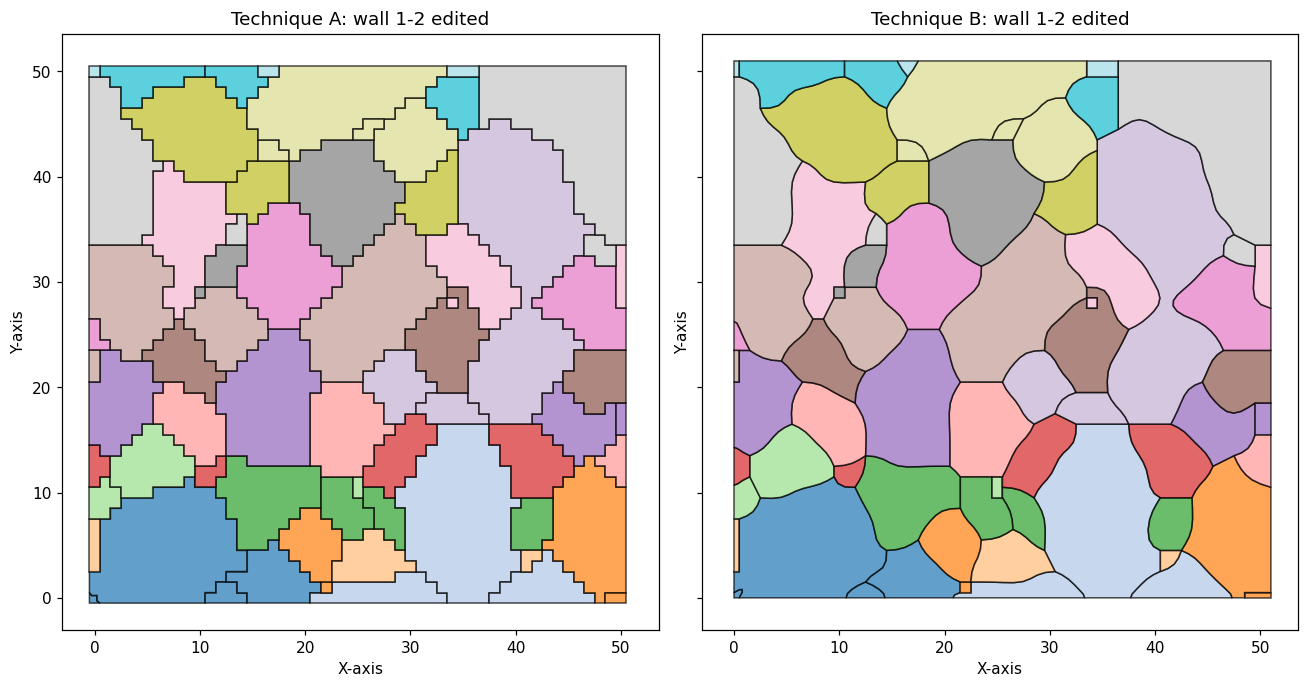

In [7]:
def bulge_one_wall(result, amplitude):
    ga, gb, ia, ib, shared = any_shared_pair(result)
    pa, pb = _editable(result[ga]), _editable(result[gb])
    total_before = sum(p.area for p in result.values())
    pa.subdivide_segment(ia, n=3)
    coords = pa.ring.segments[ia].get_node_coords()
    tangent = coords[-1] - coords[0]
    normal = np.array([-tangent[1], tangent[0]])
    normal = normal / np.linalg.norm(normal)
    new_coords = coords.copy()
    for k in range(1, len(coords) - 1):
        new_coords[k] = new_coords[k] + amplitude * normal
    pa.edit_segment(ia, new_coords)
    no_gap = np.array_equal(pa.ring.segments[ia].get_node_coords(),
                            pb.ring.segments[ib].get_node_coords())
    total_after = sum(p.area for p in result.values())
    return ga, gb, no_gap, total_before, total_after

fig, axes = plt.subplots(1, 2, figsize=(12, 6), dpi=110, sharex=True, sharey=True)

gaA, gbA, no_gapA, beforeA, afterA = bulge_one_wall(resultA, amplitude=0.4)
gsviz.plot_multipolygon_geometric(
    MultiPolygon([p.make_shapely() for p in resultA.values()]), fig=fig, ax=axes[0])
axes[0].set_title(f'Technique A: wall {gaA}-{gbA} edited')

gaB, gbB, no_gapB, beforeB, afterB = bulge_one_wall(resultB, amplitude=0.4)
gsviz.plot_multipolygon_geometric(
    MultiPolygon([p.make_shapely() for p in resultB.values()]), fig=fig, ax=axes[1])
axes[1].set_title(f'Technique B: wall {gaB}-{gbB} edited')
fig.tight_layout()

print(f"Technique A: no gap={no_gapA}, area {beforeA:.4f} -> {afterA:.4f} "
     f"(conserved: {np.isclose(beforeA, afterA)})")
print(f"Technique B: no gap={no_gapB}, area {beforeB:.4f} -> {afterB:.4f} "
     f"(conserved: {np.isclose(beforeB, afterB)})")